In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
train_dir = "E:\\Pyhton code\\Data Sets\\archive\\melanoma_cancer_dataset\\train"
test_dir = "E:\\Pyhton code\\Data Sets\\archive\\melanoma_cancer_dataset\\test"

In [3]:
import os
print(os.listdir(train_dir))

['benign', 'malignant']


In [4]:
for cls in os.listdir(train_dir):

    path = os.path.join(train_dir, cls)

    print(cls, len(os.listdir(path)))

benign 5000
malignant 4605


In [5]:
for cls in os.listdir(test_dir):
    
    path = os.path.join(test_dir, cls)

    print(cls, len(os.listdir(path)))

benign 500
malignant 500


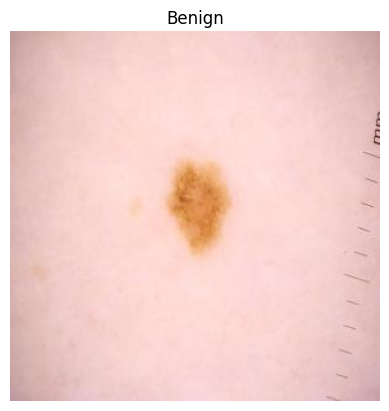

In [6]:
#visualize images
benign_path = os.path.join(train_dir, "benign")

image_name = os.listdir(benign_path)[0]

image_path = os.path.join(benign_path, image_name)

img = plt.imread(image_path)

plt.imshow(img)

plt.title("Benign")

plt.axis("off")

plt.show()

In [7]:
print(img.shape)

(300, 300, 3)


In [8]:
# ===================================
# Image Transform
# ===================================
import torchvision.transforms as transforms
transform = transforms.Compose([

    transforms.Resize((64, 64)),

    transforms.ToTensor()

])

In [9]:
# ===================================
# Training Dataset
# ===================================

from torchvision import datasets
train_dataset = datasets.ImageFolder(

    root=train_dir,

    transform=transform

)

# ===================================
# Testing Dataset
# ===================================

test_dataset = datasets.ImageFolder(

    root=test_dir,

    transform=transform

)

In [10]:
print(train_dataset)

Dataset ImageFolder
    Number of datapoints: 9605
    Root location: E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [11]:
print(train_dataset.classes)

['benign', 'malignant']


In [12]:
print(train_dataset.class_to_idx)

{'benign': 0, 'malignant': 1}


In [13]:
print(len(train_dataset))

print(len(test_dataset))

9605
1000


In [14]:
image, label = train_dataset[0]

print(image.shape)

print(label)

torch.Size([3, 64, 64])
0


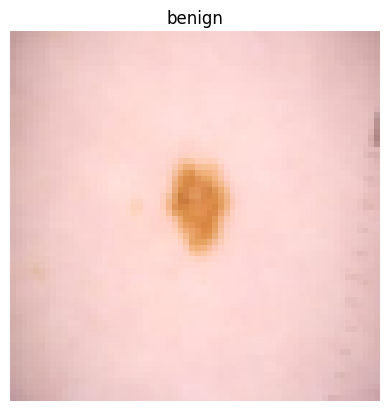

In [15]:
plt.imshow(image.permute(1, 2, 0))

plt.title(train_dataset.classes[label])

plt.axis("off")

plt.show()

In [45]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [46]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = r"E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\train"
test_dir = r"E:\Pyhton code\Data Sets\archive\melanoma_cancer_dataset\test"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [47]:
import torch.nn as nn

class ANN(nn.Module):

    def __init__(self):

        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(

            nn.Linear(64 * 64 * 3, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 2)

        )

    def forward(self, x):

        x = self.flatten(x)

        x = self.network(x)

        return x

In [48]:
model = ANN().to(device)

print(model)

ANN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [49]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [50]:
epochs = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(epochs):

    ##############################
    # Training
    ##############################

    model.train()

    train_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    train_loss /= len(train_loader)

    train_acc = 100 * correct / total

    ##############################
    # Validation
    ##############################

    model.eval()

    val_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()

            total += labels.size(0)

    val_loss /= len(test_loader)

    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/10] | Train Loss: 0.4981 | Train Acc: 74.31% | Val Loss: 0.3476 | Val Acc: 84.90%
Epoch [2/10] | Train Loss: 0.3647 | Train Acc: 83.13% | Val Loss: 0.3763 | Val Acc: 82.70%
Epoch [3/10] | Train Loss: 0.3704 | Train Acc: 82.99% | Val Loss: 0.3064 | Val Acc: 87.70%
Epoch [4/10] | Train Loss: 0.3295 | Train Acc: 85.26% | Val Loss: 0.3843 | Val Acc: 85.90%
Epoch [5/10] | Train Loss: 0.3157 | Train Acc: 85.94% | Val Loss: 0.3133 | Val Acc: 87.70%
Epoch [6/10] | Train Loss: 0.3075 | Train Acc: 86.33% | Val Loss: 0.2904 | Val Acc: 88.20%
Epoch [7/10] | Train Loss: 0.2980 | Train Acc: 87.23% | Val Loss: 0.3188 | Val Acc: 87.70%
Epoch [8/10] | Train Loss: 0.2950 | Train Acc: 87.35% | Val Loss: 0.2991 | Val Acc: 88.80%
Epoch [9/10] | Train Loss: 0.3058 | Train Acc: 86.77% | Val Loss: 0.3127 | Val Acc: 88.50%
Epoch [10/10] | Train Loss: 0.2835 | Train Acc: 87.65% | Val Loss: 0.2783 | Val Acc: 88.20%


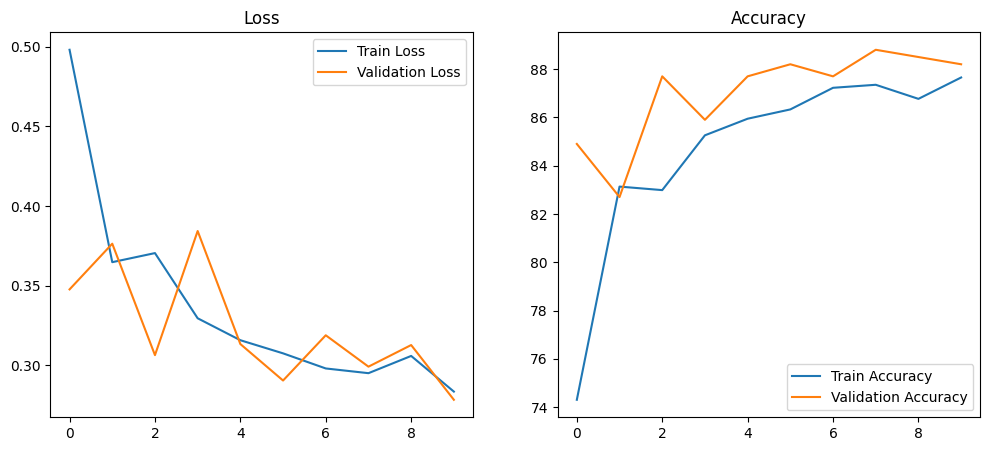

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)

plt.plot(train_accs,label="Train Accuracy")
plt.plot(val_accs,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.show()

In [52]:
from sklearn.metrics import accuracy_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())

        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true,y_pred)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 88.20%


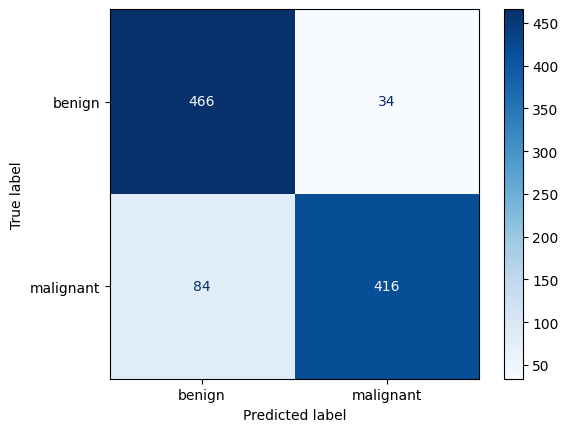

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")

plt.show()

In [54]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

      benign       0.85      0.93      0.89       500
   malignant       0.92      0.83      0.88       500

    accuracy                           0.88      1000
   macro avg       0.89      0.88      0.88      1000
weighted avg       0.89      0.88      0.88      1000

